In [65]:
import shap # Shapley Additive exPlanations - Based on Game Theory, used for explanation of model - RF, XGBoost, NN. 
# Feature importance, Interpretability, Feature distribution.
import os
import gc
import re
import pickle
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score
from lightgbm import LGBMClassifier, LGBMRegressor
from collections import Counter

In [66]:
# Data Load. check the number of rows and columns. Result 303 rows and 14 columns
data = pd.read_csv("data/data.csv")
print("Data Shape : {}".format(data.shape))

Data Shape : (303, 14)


In [67]:
# Visually see the data. age, sex, cp? trtbps? cholesterol? fbs? restecg? thalachh? exng? oldpeak? slp? caa? thall? output will be the target.
data

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [68]:
# Checking summary with discribe. 303 counts, mean age is 54.
data.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [70]:
# Check if the target is binary.
data['output'].unique()

array([1, 0], dtype=int64)

1    165
0    138
Name: output, dtype: int64


<Axes: xlabel='output', ylabel='count'>

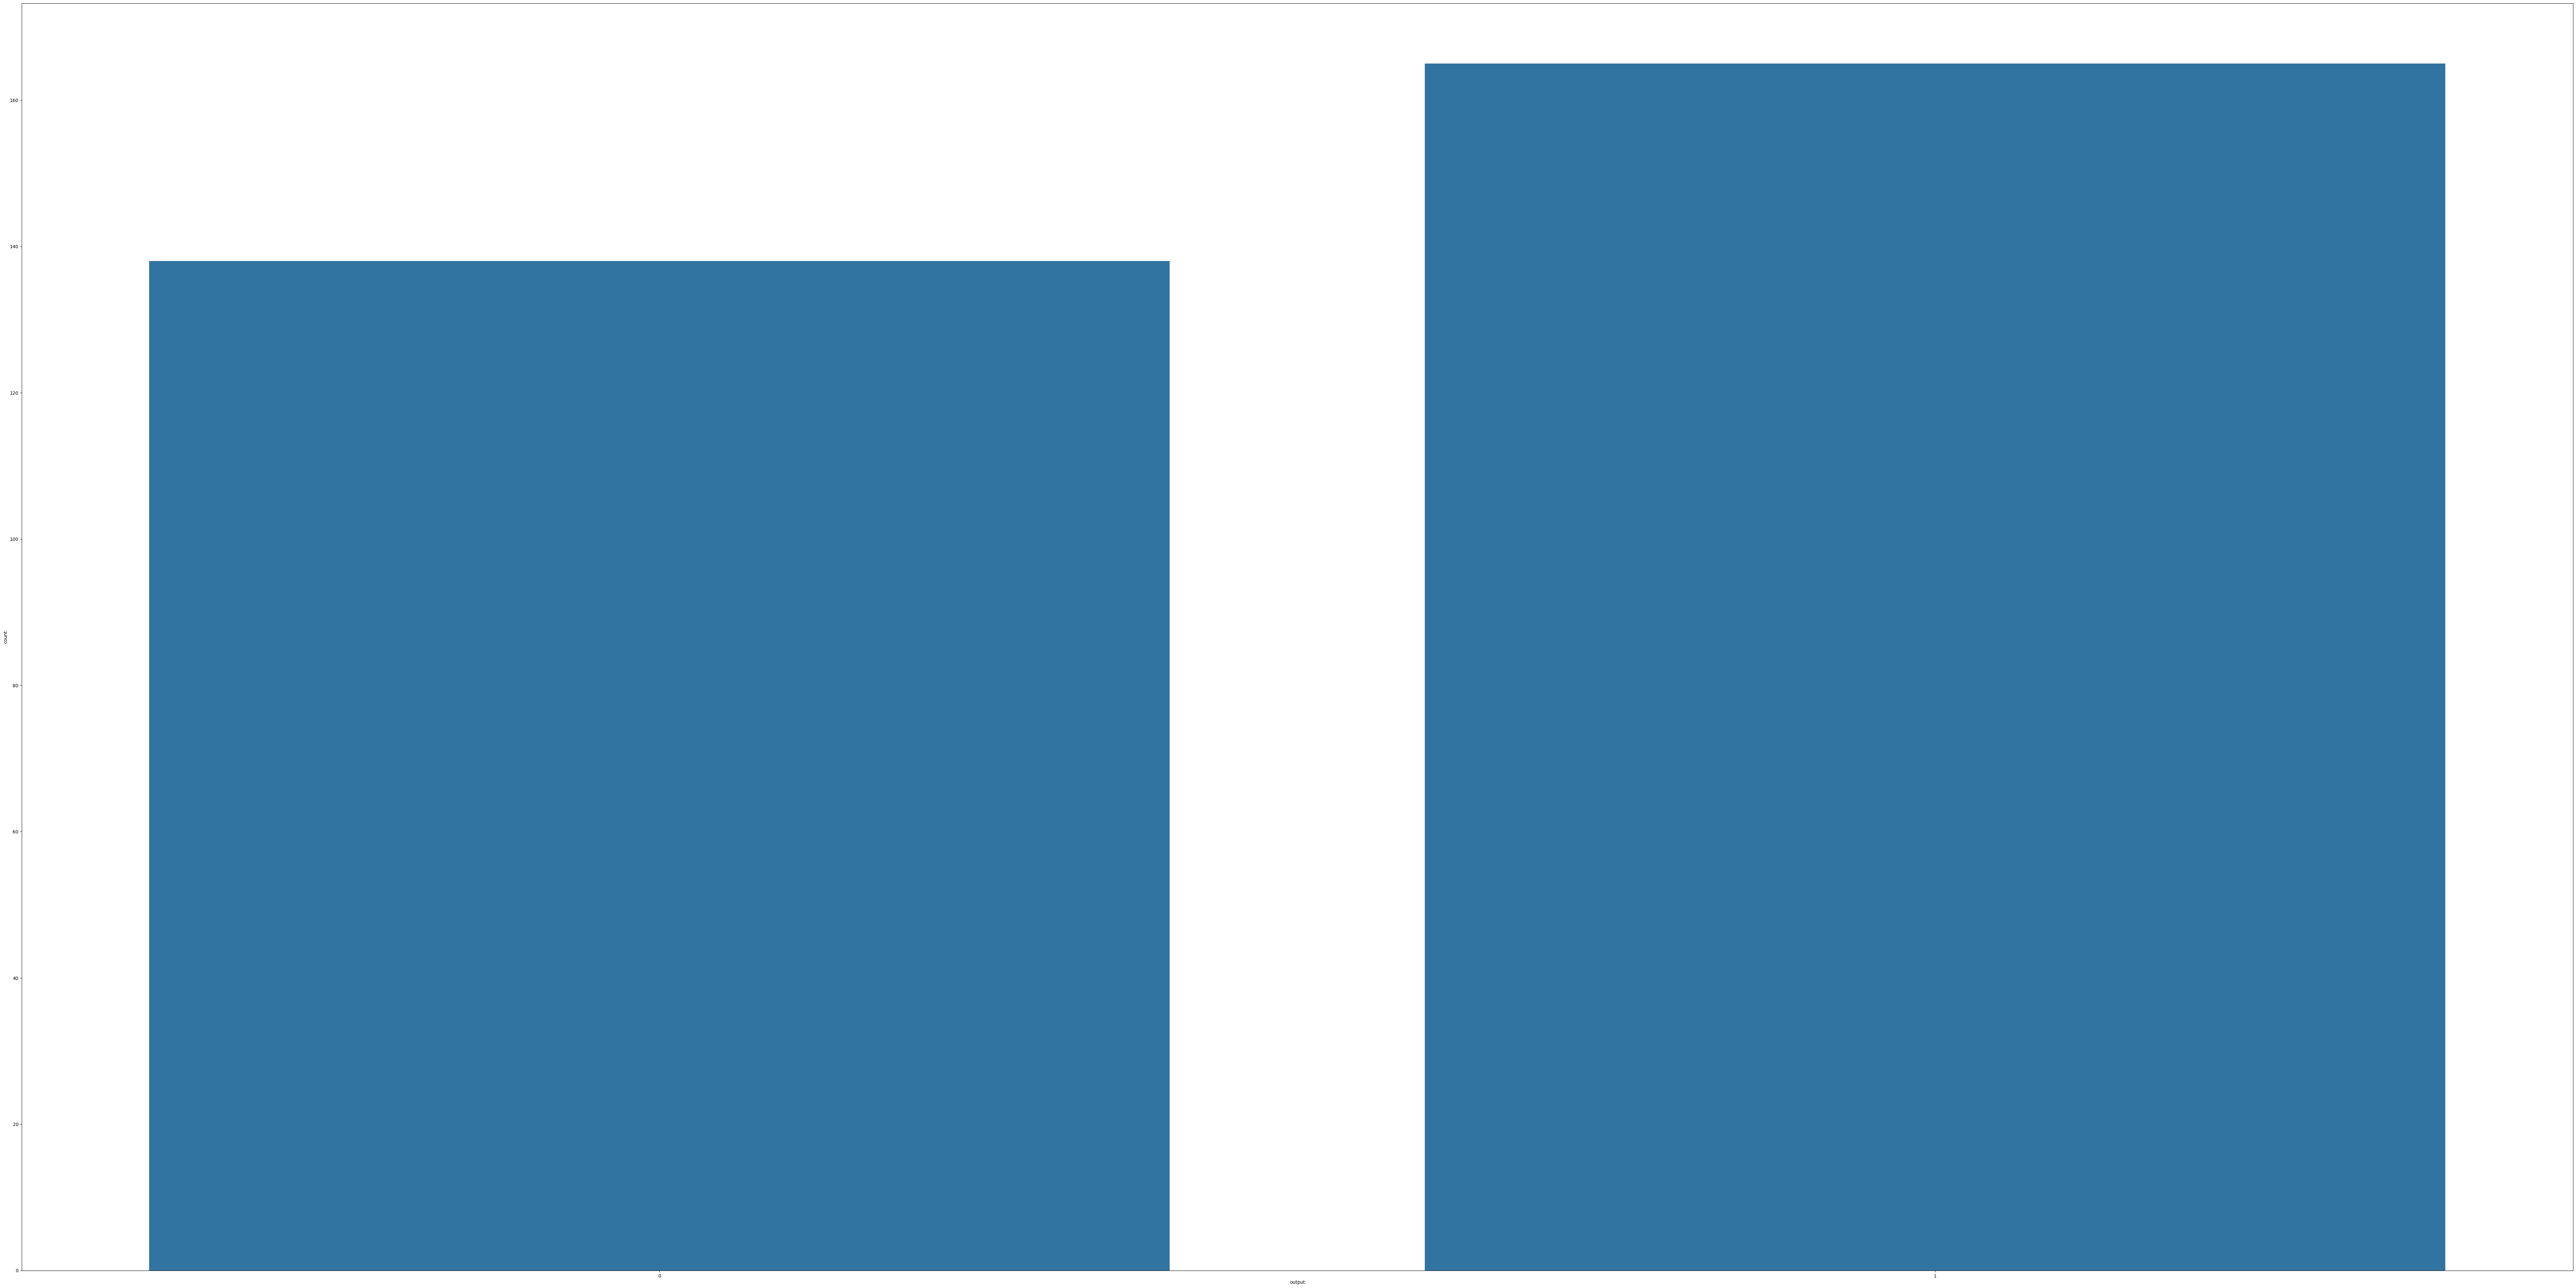

In [71]:
# target is output. Check target distribution with visualisation. Yes is 165 0 is no. very balanced dataset target.
target = data['output']
target_dist = data.output.value_counts()
print(target_dist)
sns.countplot(x=target)

In [73]:
# data columns -> one by one. missper = data[name] all sum up device by 303. Check individual missing percentage by appending to missing list
col = []
missing = []
for name in data.columns:
    # Missing
    missper = data[name].isnull().sum() / data.shape[0]
    missing.append(round(missper, 4))

In [74]:
missing

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [10]:
# Checking unique values. level = data['name'].dropna() -> dropping each. 
col = []
level = []
for name in data.columns:
    
    # Leveling
    lel = data[name].dropna()
    level.append(len(list(set(lel))))

    # Columns
    col.append(name)

In [11]:
level

[41, 2, 4, 49, 152, 2, 3, 91, 2, 40, 3, 5, 4, 2]

In [12]:
# Data Missing에 대해 DataFrame을 만들어줌
summary = pd.concat([pd.DataFrame(col, columns=['name']), 
                     pd.DataFrame(missing, columns=['Missing Percentage']), 
                     pd.DataFrame(level, columns=['Unique'])], axis=1)

In [13]:
summary

,name,Missing Percentage,Unique
0,age,0.0,41
1,sex,0.0,2
2,cp,0.0,4
3,trtbps,0.0,49
4,chol,0.0,152
5,fbs,0.0,2
6,restecg,0.0,3
7,thalachh,0.0,91
8,exng,0.0,2
9,oldpeak,0.0,40


In [75]:
summary[summary['Unique'] <=1].shape # Unique 의 갯수가 1개이하인 것들을추려냄

(0, 3)

In [76]:
summary[summary['Missing Percentage'] >0.8].shape

(0, 3)

In [77]:
# Data Cutting
drop_col = summary['name'][(summary['Unique'] <= 1) | (summary['Missing Percentage'] >= 0.8)]
data.drop(columns=drop_col, inplace=True)
print(">>>> Data Shape : {}".format(data.shape))

>>>> Data Shape : (303, 14)


In [78]:
data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
298    False
299    False
300    False
301    False
302    False
Length: 303, dtype: bool

In [79]:
dup_rows = data[data.duplicated()]

In [80]:
dup_rows

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [81]:
# Checking for juplicate entries
dup_rows = data[data.duplicated()]
print("# of duplicated entries are : {}".format(dup_rows.shape))

# of duplicated entries are : (1, 14)


In [82]:
dup_rows.index[0]

164

In [83]:
data.drop([164], inplace=True)

In [84]:
data.shape

(302, 14)

In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trtbps    302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalachh  302 non-null    int64  
 8   exng      302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slp       302 non-null    int64  
 11  caa       302 non-null    int64  
 12  thall     302 non-null    int64  
 13  output    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


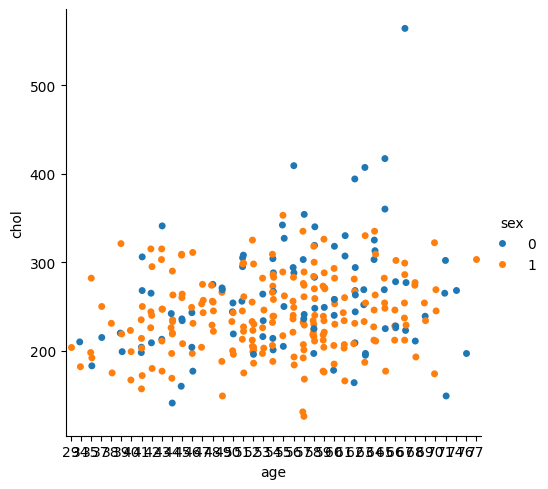

In [86]:
# Categorical plots
sns.catplot(x="age", y="chol", hue='sex', data=data)

In [27]:
data['age'].std()

9.047969746247457

In [28]:
# z-score
from scipy import stats

# 절대값을 씌우는 이유는 방향을 구분하지 않고 얼마만큼 떨어졌는지만 판단하기 위함
z = np.abs(stats.zscore(data))

In [29]:
z

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,0.949794,0.682656,1.976470,0.764066,0.261285,2.389793,1.002541,0.018826,0.698344,1.084022,2.271182,0.714911,2.147955,0.917313
1,1.928548,0.682656,1.005911,0.091401,0.067741,0.418446,0.901657,1.636979,0.698344,2.118926,2.271182,0.714911,0.513994,0.917313
2,1.485726,1.464866,0.035352,0.091401,0.822564,0.418446,1.002541,0.980971,0.698344,0.307844,0.979514,0.714911,0.513994,0.917313
3,0.174856,0.682656,0.035352,0.661712,0.203222,0.418446,0.901657,1.243374,0.698344,0.209608,0.979514,0.714911,0.513994,0.917313
4,0.285561,1.464866,0.935208,0.661712,2.080602,0.418446,0.901657,0.587366,1.431958,0.382092,0.979514,0.714911,0.513994,0.917313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.285561,1.464866,0.935208,0.478910,0.106449,0.418446,0.901657,1.161988,1.431958,0.727060,0.645834,0.714911,1.119967,1.090140
299,1.042904,0.682656,1.976470,1.232023,0.338703,0.418446,0.901657,0.768384,0.698344,0.135360,0.645834,0.714911,1.119967,1.090140
300,1.503322,0.682656,0.935208,0.707035,1.035462,2.389793,0.901657,0.374779,0.698344,2.032684,0.645834,1.274980,1.119967,1.090140
301,0.285561,0.682656,0.935208,0.091401,2.235438,0.418446,0.901657,1.511859,1.431958,0.135360,0.645834,0.280034,1.119967,1.090140


In [30]:
# Searching - 3시그마 이상
th = 3.5
print(np.where(z['trtbps'] > th))
z[z['trtbps'] > th]

(array([222], dtype=int64),)


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
223,0.174856,1.464866,0.935208,3.900776,0.803209,2.389793,1.002541,0.72465,1.431958,2.550136,2.271182,1.27498,1.119967,1.09014


In [31]:
z[z['trtbps'] > th]

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
223,0.174856,1.464866,0.935208,3.900776,0.803209,2.389793,1.002541,0.72465,1.431958,2.550136,2.271182,1.27498,1.119967,1.09014


In [32]:
for i in range(z.shape[0]):
    if z['trtbps'].iloc[i] > th:
        print(z['trtbps'].iloc[i])

3.9007763959763575


In [33]:
data.iloc[222,:]

age          56.0
sex           0.0
cp            0.0
trtbps      200.0
chol        288.0
fbs           1.0
restecg       0.0
thalachh    133.0
exng          1.0
oldpeak       4.0
slp           0.0
caa           2.0
thall         3.0
output        0.0
Name: 223, dtype: float64

In [34]:
tmp = np.where(z > th)

In [36]:
tmp[0]

array([ 48,  85, 203, 220, 222, 280], dtype=int64)

In [37]:
# cleaning
clean_data = data[(z < th).all(axis=1)]

In [38]:
data.shape

(302, 14)

In [39]:
clean_data.shape

(296, 14)

In [40]:
corr = clean_data.corr()
corr.style.background_gradient(cmap='PuOr')

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
age,1.000000,-0.085240,-0.065577,0.290894,0.197038,0.126261,-0.104934,-0.402341,0.099825,0.204457,-0.158288,0.303493,0.054249,-0.225706
sex,-0.085240,1.000000,-0.048118,-0.038688,-0.185396,0.048989,-0.086166,-0.054444,0.137809,0.133869,-0.049382,0.130565,0.232080,-0.288141
cp,-0.065577,-0.048118,1.000000,0.071285,-0.106552,0.114433,0.048470,0.295250,-0.385506,-0.121408,0.096183,-0.188514,-0.163679,0.420770
trtbps,0.290894,-0.038688,0.071285,1.000000,0.158769,0.158238,-0.105943,-0.035640,0.052014,0.147208,-0.084286,0.071825,0.042910,-0.127137
chol,0.197038,-0.185396,-0.106552,0.158769,1.000000,0.017787,-0.138869,-0.020666,0.082983,0.072479,0.004133,0.115273,0.070367,-0.115678
fbs,0.126261,0.048989,0.114433,0.158238,0.017787,1.000000,-0.087717,-0.007856,0.001107,-0.005192,-0.043277,0.145716,-0.013174,-0.010281
restecg,-0.104934,-0.086166,0.048470,-0.105943,-0.138869,-0.087717,1.000000,0.039514,-0.081294,-0.049914,0.088361,-0.073571,-0.004287,0.143045
thalachh,-0.402341,-0.054444,0.295250,-0.035640,-0.020666,-0.007856,0.039514,1.000000,-0.378692,-0.344756,0.386409,-0.235337,-0.109780,0.423404
exng,0.099825,0.137809,-0.385506,0.052014,0.082983,0.001107,-0.081294,-0.378692,1.000000,0.290216,-0.246058,0.131623,0.225270,-0.428302
oldpeak,0.204457,0.133869,-0.121408,0.147208,0.072479,-0.005192,-0.049914,-0.344756,0.290216,1.000000,-0.544604,0.219808,0.178083,-0.423929


In [41]:
#One-Hot encoding
clean_data = pd.get_dummies(clean_data, columns=['cp', 'restecg','thall', 'slp'])

In [42]:
clean_data

,age,sex,trtbps,chol,fbs,thalachh,exng,oldpeak,caa,output,...,cp_3,restecg_0,restecg_1,restecg_2,thall_1,thall_2,thall_3,slp_0,slp_1,slp_2
0,63,1,145,233,1,150,0,2.3,0,1,...,1,1,0,0,1,0,0,1,0,0
1,37,1,130,250,0,187,0,3.5,0,1,...,0,0,1,0,0,1,0,1,0,0
2,41,0,130,204,0,172,0,1.4,0,1,...,0,1,0,0,0,1,0,0,0,1
3,56,1,120,236,0,178,0,0.8,0,1,...,0,0,1,0,0,1,0,0,0,1
4,57,0,120,354,0,163,1,0.6,0,1,...,0,0,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140,241,0,123,1,0.2,0,0,...,0,0,1,0,0,0,1,0,1,0
299,45,1,110,264,0,132,0,1.2,0,0,...,1,0,1,0,0,0,1,0,1,0
300,68,1,144,193,1,141,0,3.4,2,0,...,0,0,1,0,0,0,1,0,1,0
301,57,1,130,131,0,115,1,1.2,1,0,...,0,0,1,0,0,0,1,0,1,0


In [43]:
Y = clean_data['output']
X = clean_data.drop(columns=['output'])

In [44]:
idx = list(range(X.shape[0]))
train_idx, valid_idx = train_test_split(idx, test_size=0.3, random_state=42)
print(">>>> # of Train data : {}".format(len(train_idx)))
print(">>>> # of valid data : {}".format(len(valid_idx)))

>>>> # of Train data : 207
>>>> # of valid data : 89


In [45]:
print("X Shape >>>> {}".format(X.shape))
print("Y Shape >>>> {}".format(Y.shape))

X Shape >>>> (296, 22)
Y Shape >>>> (296,)


In [46]:
# n_estimators
n_tree = [5, 10, 20, 30, 50]
# learning_rate
l_rate = [0.1, 0.3]
# max_depth
m_depth = [3, 5]
# reg_alpha
L1_norm = [0.3, 0.5]

# Modeling
save_n = []
save_l = []
save_m = []
save_L1 = []
f1_score_ = []

cnt = 0

for n in n_tree:
    for l in l_rate:
        for m in m_depth:
            for L1 in L1_norm:
                
                print(">>> {} <<<".format(cnt))
                cnt +=1
                print("n_estimators : {}, learning_rate : {}, max_depth : {}, reg_alpha : {}".format(n, l, m, L1))
                model = LGBMClassifier(n_estimators=n, learning_rate=l, 
                                       max_depth=m, reg_alpha=L1, 
                                       n_jobs=-1, objective='cross_entropy')
                model.fit(X.iloc[train_idx], Y.iloc[train_idx])
                
                
                # Train Acc
                y_pre_train = model.predict(X.iloc[train_idx])
                cm_train = confusion_matrix(Y.iloc[train_idx], y_pre_train)
                print("Train Confusion Matrix")
                print(cm_train)
                print("Train Acc : {}".format((cm_train[0,0] + cm_train[1,1])/cm_train.sum()))
                print("Train F1-Score : {}".format(f1_score(Y.iloc[train_idx], y_pre_train)))

                # Test Acc
                y_pre_test = model.predict(X.iloc[valid_idx])
                cm_test = confusion_matrix(Y.iloc[valid_idx], y_pre_test)
                print("Test Confusion Matrix")
                print(cm_test)
                print("TesT Acc : {}".format((cm_test[0,0] + cm_test[1,1])/cm_test.sum()))
                print("Test F1-Score : {}".format(f1_score(Y.iloc[valid_idx], y_pre_test)))
                print("-----------------------------------------------------------------------")
                print("-----------------------------------------------------------------------")
                save_n.append(n)
                save_l.append(l)
                save_m.append(m)
                save_L1.append(L1)
                f1_score_.append(f1_score(Y.iloc[valid_idx], y_pre_test))


                #joblib.dump(model, './LightGBM_model/Result_{}_{}_{}_{}_{}.pkl'.format(n, l, m, L1, round(save_acc[-1], 4)))
                #gc.collect()

>>> 0 <<<
n_estimators : 5, learning_rate : 0.1, max_depth : 3, reg_alpha : 0.3
[LightGBM] [Info] [cross_entropy:Init]: (objective) labels passed interval [0, 1] check
[LightGBM] [Info] [cross_entropy:Init]: (metric) labels passed interval [0, 1] check
[LightGBM] [Info] [cross_entropy:Init]: sum-of-weights = 207.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000550 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 223
[LightGBM] [Info] Number of data points in the train set: 207, number of used features: 18
[LightGBM] [Info] [cross_entropy:BoostFromScore]: pavg = 0.521739 -> initscore = 0.087011
[LightGBM] [Info] Start training from score 0.087011
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

In [47]:
print(">>> {} <<<\nBest Test f1-score : {}\nBest n_estimators : {}\nBest Learning Rate : {}\nBest Max_depth : {}\nBest L1-norm : {}".format(np.argmax(f1_score_),
                                                                                                                                            f1_score_[np.argmax(f1_score_)], 
                                                                                                                                            save_n[np.argmax(f1_score_)],
                                                                                                                                            save_l[np.argmax(f1_score_)],
                                                                                                                                            save_m[np.argmax(f1_score_)],
                                                                                                                                            save_L1[np.argmax(f1_score_)]))

>>> 5 <<<
Best Test f1-score : 0.9174311926605505
Best n_estimators : 5
Best Learning Rate : 0.3
Best Max_depth : 3
Best L1-norm : 0.5


In [48]:
best_model = LGBMClassifier(n_estimators=save_n[np.argmax(f1_score_)], learning_rate=save_l[np.argmax(f1_score_)], 
                           max_depth=save_m[np.argmax(f1_score_)], reg_alpha=save_L1[np.argmax(f1_score_)], objective='cross_entropy', 
                           random_state=119)
best_model.fit(X.iloc[train_idx], Y.iloc[train_idx])

# Train Acc
y_pre_train = best_model.predict(X.iloc[train_idx])
cm_train = confusion_matrix(Y.iloc[train_idx], y_pre_train)
print("Train Confusion Matrix")
print(cm_train)
print("Train Acc : {}".format((cm_train[0,0] + cm_train[1,1])/cm_train.sum()))
print("Train F1-Score : {}".format(f1_score(Y.iloc[train_idx], y_pre_train)))

# Test Acc
y_pre_test = best_model.predict(X.iloc[valid_idx])
cm_test = confusion_matrix(Y.iloc[valid_idx], y_pre_test)
print("Test Confusion Matrix")
print(cm_test)
print("TesT Acc : {}".format((cm_test[0,0] + cm_test[1,1])/cm_test.sum()))
print("Test F1-Score : {}".format(f1_score(Y.iloc[valid_idx], y_pre_test)))

[LightGBM] [Info] [cross_entropy:Init]: (objective) labels passed interval [0, 1] check
[LightGBM] [Info] [cross_entropy:Init]: (metric) labels passed interval [0, 1] check
[LightGBM] [Info] [cross_entropy:Init]: sum-of-weights = 207.000000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 223
[LightGBM] [Info] Number of data points in the train set: 207, number of used features: 18
[LightGBM] [Info] [cross_entropy:BoostFromScore]: pavg = 0.521739 -> initscore = 0.087011
[LightGBM] [Info] Start training from score 0.087011
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

In [49]:
feature_map = pd.DataFrame(sorted(zip(best_model.feature_importances_, X.columns), reverse=True), columns=['Score', 'Feature'])
print(feature_map)

    Score    Feature
0       4        caa
1       4        age
2       3       cp_0
3       2     trtbps
4       2    thall_2
5       2      slp_1
6       2        sex
7       2    oldpeak
8       2       chol
9       1    thall_3
10      1   thalachh
11      1      slp_2
12      1  restecg_0
13      1       exng
14      0    thall_1
15      0      slp_0
16      0  restecg_2
17      0  restecg_1
18      0        fbs
19      0       cp_3
20      0       cp_2
21      0       cp_1


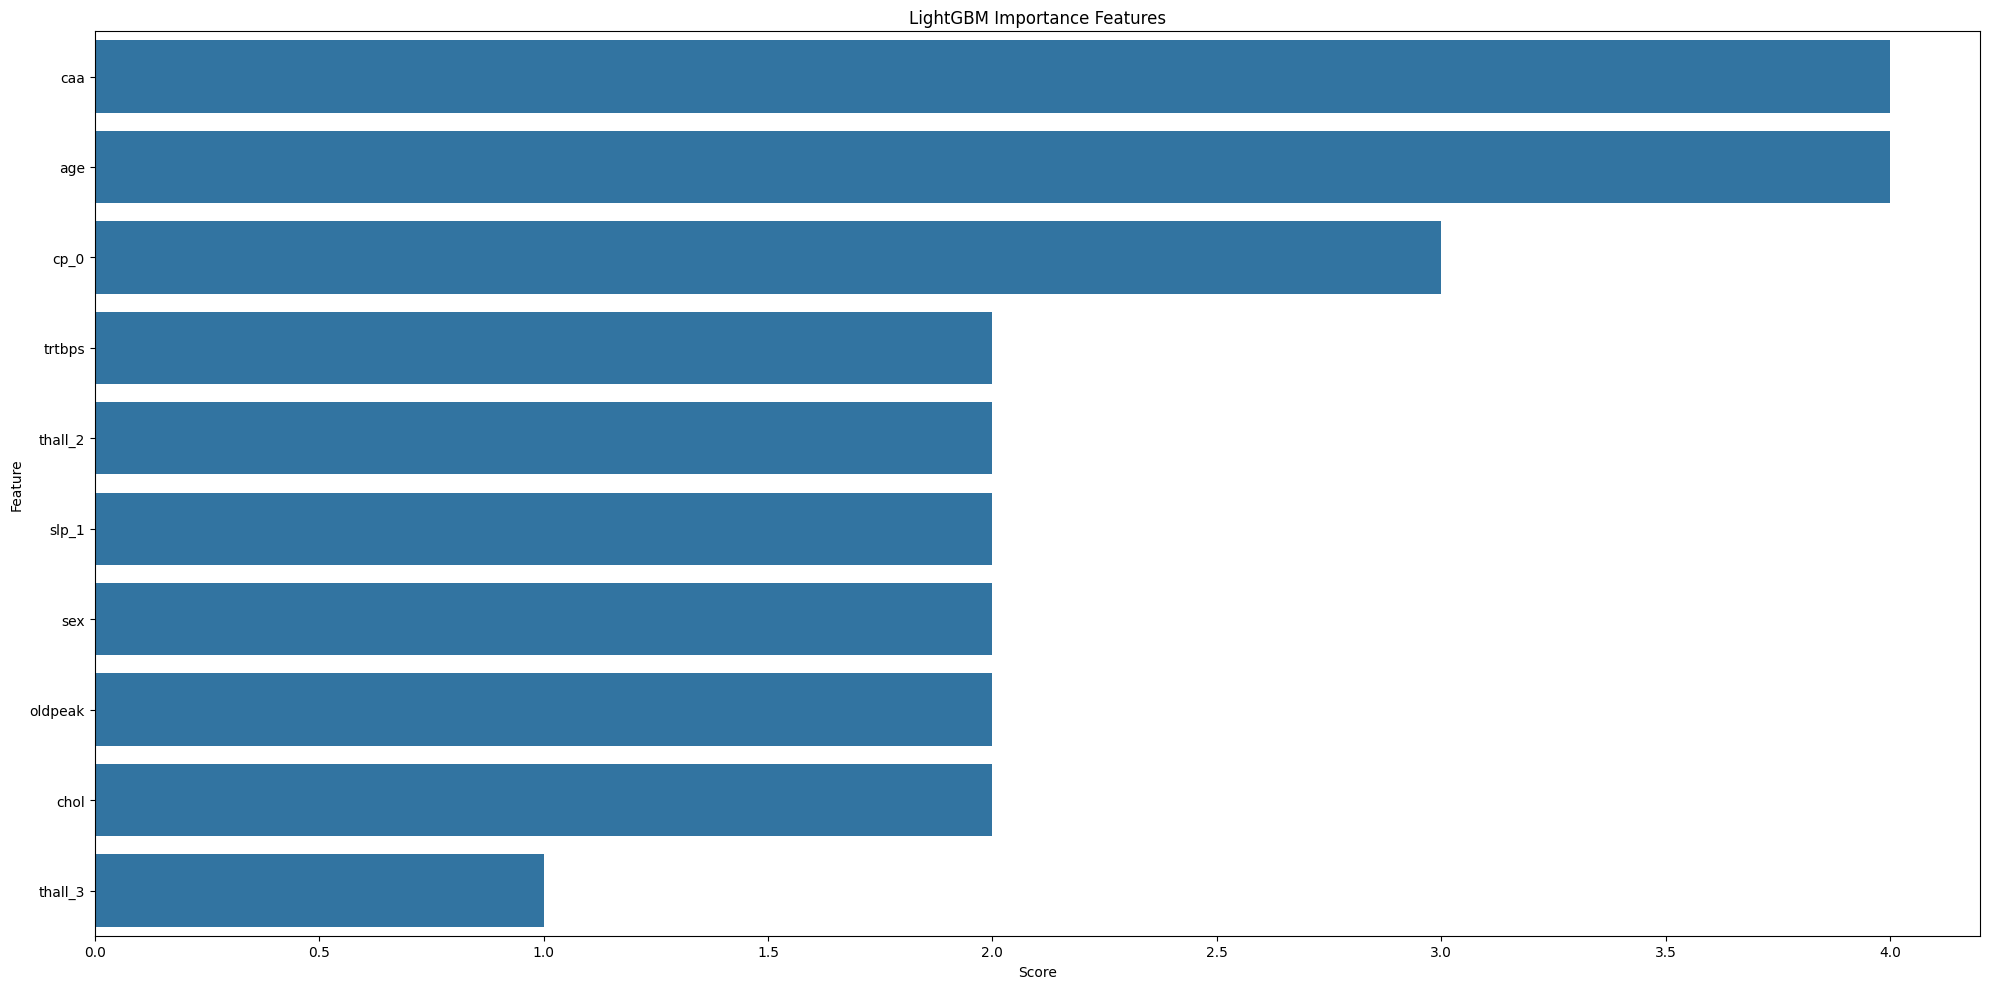

In [50]:
# Importance Score Top 10
feature_map_10 = feature_map.iloc[:10]
plt.figure(figsize=(20, 10))
sns.barplot(x="Score", y="Feature", data=feature_map_10.sort_values(by="Score", ascending=False), errwidth=40)
plt.title('LightGBM Importance Features')
plt.tight_layout()
plt.show()

In [51]:
# SHAP Explainer 만들기
explainer = shap.TreeExplainer(best_model)
# Shap values 계산
shap_values = explainer.shap_values(X)

In [52]:
X.shape

(296, 22)

In [53]:
shap_values.shape

(296, 22)

In [54]:
# Plot Seting
shap.initjs()

In [55]:
select_col = ['caa', 'cp_0', 'thall_2','thall_3','oldpeak'] #,'age','slp_1', 'sex']

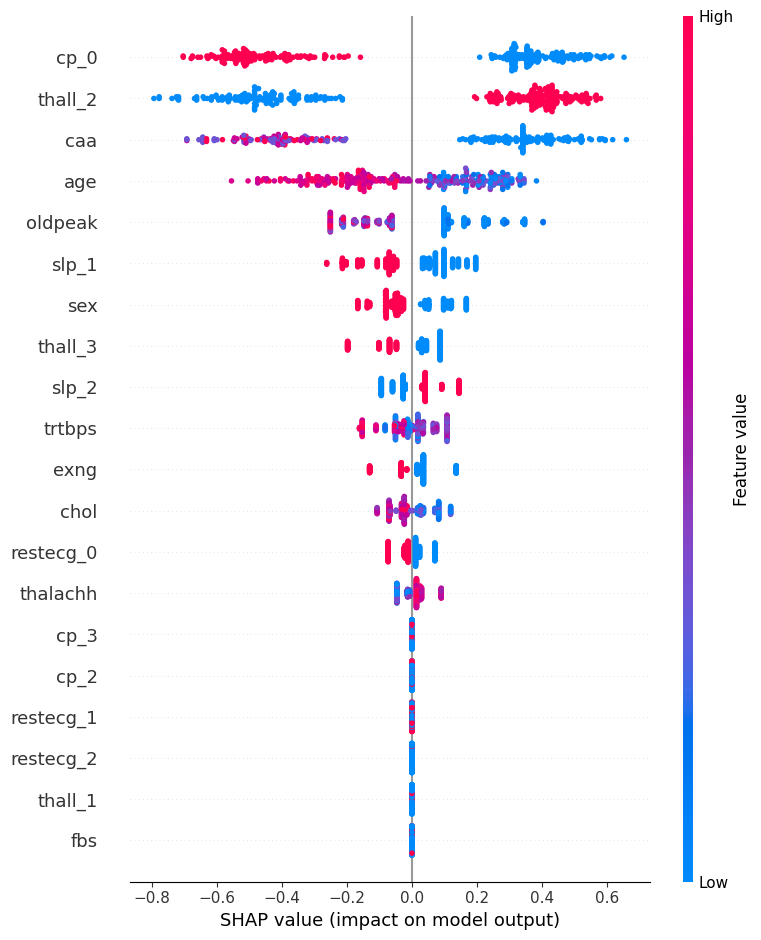

In [56]:
shap.summary_plot(shap_values, X)

In [57]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, export_graphviz

In [59]:
X[select_col]

,caa,cp_0,thall_2,thall_3,oldpeak
0,0,0,0,0,2.3
1,0,0,1,0,3.5
2,0,0,1,0,1.4
3,0,0,1,0,0.8
4,0,1,1,0,0.6
...,...,...,...,...,...
298,0,1,0,1,0.2
299,0,0,0,1,1.2
300,2,1,0,1,3.4
301,1,1,0,1,1.2


In [60]:
# Depth 조절 Decision Tree
for i in range(2,11,1):
    print(">>>> Depth {}".format(i))

    model = DecisionTreeClassifier(max_depth=i, criterion='gini')
    model.fit(X[select_col].iloc[train_idx], Y.iloc[train_idx])

    # Train Acc
    y_pre_train = model.predict(X[select_col].iloc[train_idx])
    cm_train = confusion_matrix(Y.iloc[train_idx], y_pre_train)
    print("Train Confusion Matrix")
    print(cm_train)
    print("Train Acc : {}".format((cm_train[0,0] + cm_train[1,1])/cm_train.sum()))
    print("Train F1-Score : {}".format(f1_score(Y.iloc[train_idx], y_pre_train)))

    # Test Acc
    y_pre_test = model.predict(X[select_col].iloc[valid_idx])
    cm_test = confusion_matrix(Y.iloc[valid_idx], y_pre_test)
    print("Train Confusion Matrix")
    print(cm_test)
    print("TesT Acc : {}".format((cm_test[0,0] + cm_test[1,1])/cm_test.sum()))
    print("Test F1-Score : {}".format(f1_score(Y.iloc[valid_idx], y_pre_test)))
    print("-----------------------------------------------------------------------")
    print("-----------------------------------------------------------------------")

>>>> Depth 2
Train Confusion Matrix
[[90  9]
 [40 68]]
Train Acc : 0.7632850241545893
Train F1-Score : 0.7351351351351352
Train Confusion Matrix
[[32  3]
 [20 34]]
TesT Acc : 0.7415730337078652
Test F1-Score : 0.7472527472527473
-----------------------------------------------------------------------
-----------------------------------------------------------------------
>>>> Depth 3
Train Confusion Matrix
[[82 17]
 [14 94]]
Train Acc : 0.8502415458937198
Train F1-Score : 0.8584474885844748
Train Confusion Matrix
[[30  5]
 [14 40]]
TesT Acc : 0.7865168539325843
Test F1-Score : 0.8080808080808081
-----------------------------------------------------------------------
-----------------------------------------------------------------------
>>>> Depth 4
Train Confusion Matrix
[[87 12]
 [14 94]]
Train Acc : 0.8743961352657005
Train F1-Score : 0.8785046728971962
Train Confusion Matrix
[[29  6]
 [14 40]]
TesT Acc : 0.7752808988764045
Test F1-Score : 0.8
----------------------------------------

In [61]:
# Depth가 깊어질 수록 정확도는 높게 나오지만 해석력에 대한 가독성을 위해 Depth 5를 선택함
model = DecisionTreeClassifier(max_depth=3, criterion='gini')
model.fit(X[select_col].iloc[train_idx], Y.iloc[train_idx])

DecisionTreeClassifier(max_depth=3)

In [62]:
select_col

['caa', 'cp_0', 'thall_2', 'thall_3', 'oldpeak']

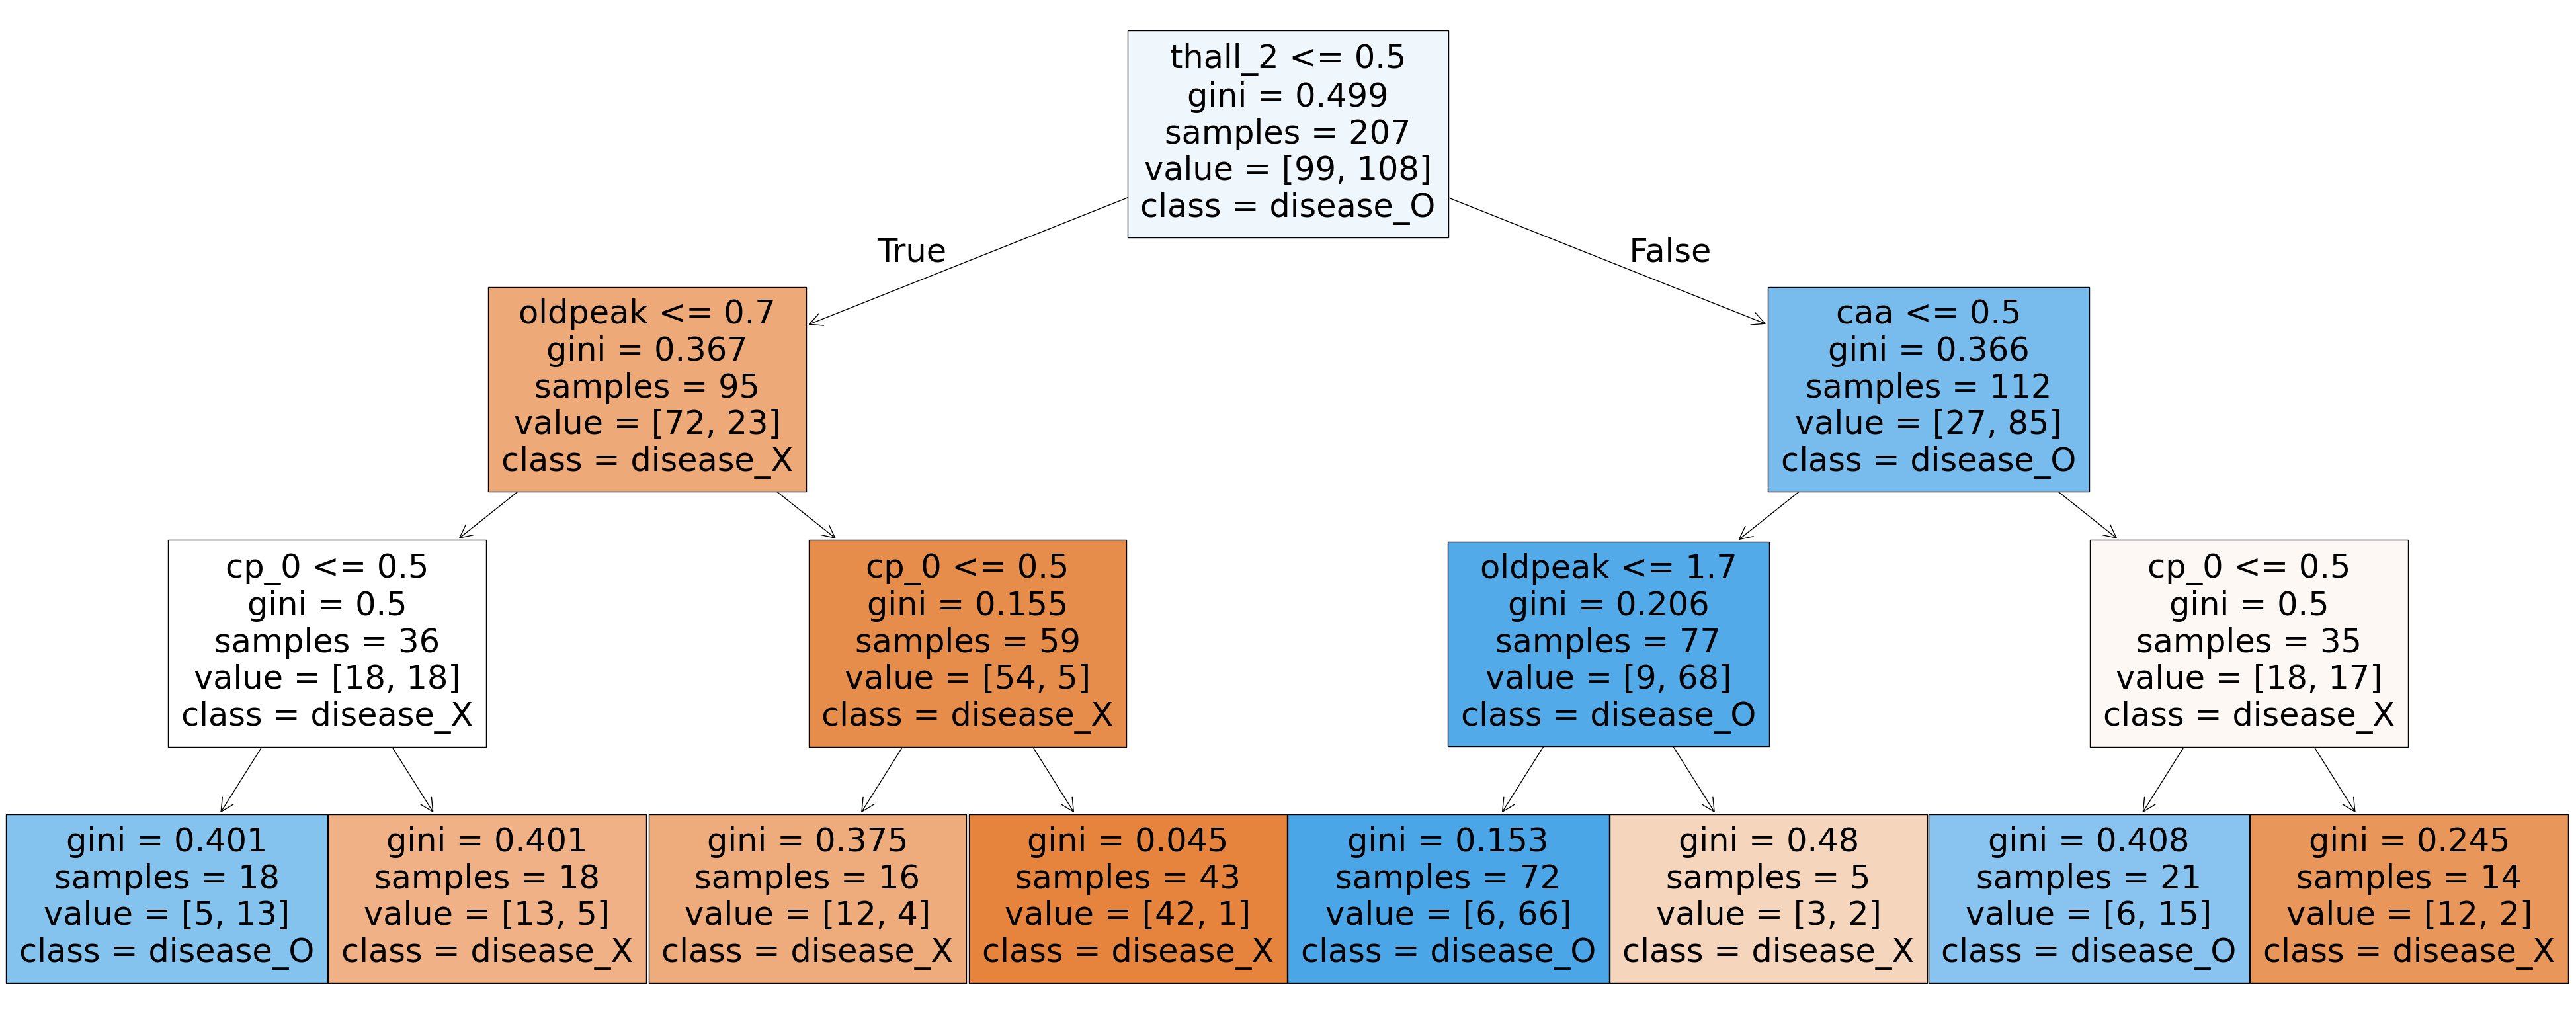

In [64]:
# Creating the tree plot (left = True, Right = False)
tree.plot_tree(model, filled=True, feature_names=select_col, class_names = ['disease_X', 'disease_O'])
plt.rcParams['figure.figsize'] = [100,50]